In [1]:
%matplotlib inline
import os
import h5py as h5
import matplotlib.pyplot as plt
#plt.style.use('bmh')
import numpy as np
import xarray as xr

import matplotlib.image as mpimg

# Doing this to get rid of annoying futurewarnings from pandas
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd

# Analyse results of numerical experiments with integrators and interpolators

Before running through this notebook, make sure to build and run the fortran code to obtain simulation data to analyse. Running through the notebook will reproduce Figs. 5, B1 and B2 from Nordam and Duran (2020), except with a somewhat reduced number of datapoints, as it takes more than a day to run the full set of simulations. Do reproduce our results exactly, expand the number of timesteps and tolerances in parameters.f90

## Define some lists and dictionaries and things for convenience

In [2]:
# List of all implemented methods
methods = ['rk1', 'rk2', 'rk3_heun', 'rk3_kutta', 'rk4']

# Number of evaluations of RHS for each call to method
callfactor = {
    'rk1'       :  1,
    'rk2'       :  2,
    'rk3_kutta' :  3,
    'rk3_heun'  :  3,
    'rk4'       :  4,
}

# Consistent colors for plotting
colordict = {
    'rk1'       :  '#1f77b4',
    'rk2'       :  '#ff7f0e',
    'rk3_kutta' :  '#2ca02c',
    'rk3_heun'  :  '#e377c2',
    'rk4'       :  '#d62728',
}

# Labels  for legends
namedict = {
    'rk1'       : 'R-K 1',
    'rk2'       : 'R-K 2',
    'rk3_kutta' : 'R-K 3 (Kutta)',
    'rk3_heun'  : 'R-K 3 (Heun)',
    'rk4'       : 'R-K 4',
}

# Resolution labels
resolutiondict = {
    'norkyst800' : '800 m',
    'nordic4'    : '4 km',
    'arctic20'   : '20 km',
}

# Interpolation labels
interpdict = {
    'linear'  : 'linear',
    'cubic'   : 'cubic spline',
    'fifth'   : 'quintic spline',
    'quintic' : 'quintic spline',
}

## Functions to read data and calculate distances

In [3]:
def get_data(hdf5filepath):
    data = {}
    keys = []
    f = h5.File(hdf5filepath, 'r')
    for k, v in f.items():
        k = float(k)
        keys.append(k)
        data[k] = v.get('X')[:]

    keys = np.array(sorted(keys))
    return keys, data

def get_distances(X0, X, relative = True):
    if relative:
        return np.sqrt(np.sum((X0 - X)**2, axis = 1)) / np.sqrt(np.sum(X0**2, axis = 1))
    else:
        return np.sqrt(np.sum((X0 - X)**2, axis = 1))

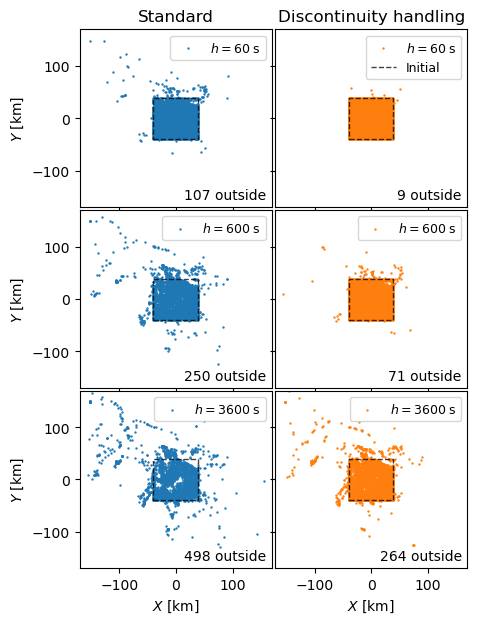

In [4]:
fig, ax = plt.subplots(ncols=2, nrows=3, sharex=True, sharey=True, figsize=(5,7))

colors = ['#1f77b4', '#ff7f0e']

X0 = np.loadtxt('../data/initial_positions_nordic4_forwards_both.txt', skiprows=1)

key = 10

for i, label in enumerate(['standard', 'discontinuity_handling']):
    for j, dt in enumerate([60., 600., 3600.]):
        keys, data = get_data(f'../results/backward_run_{label}_rk4_nordic4_linear.hdf5')
        ax[j,i].scatter(*data[dt].T/1000 - np.array([-2360, -1560])[:,None], s=0.5, alpha=1, c=colors[i], label=f'$h={int(dt)}\\;\\mathrm{{s}}$')

        xmin = np.amin(X0[:,0]) - 0.1
        xmax = np.amax(X0[:,0]) + 0.1
        ymin = np.amin(X0[:,1]) - 0.1
        ymax = np.amax(X0[:,1]) + 0.1
        X = data[dt]
        mask = (X[:,0] < xmin) | (X[:,0] > xmax) |  (X[:,1] < ymin) |  (X[:,0] > ymax)
        ax[j,i].text(160, -160, f'{np.sum(mask)} outside', ha='right', va='bottom')

ax[0,0].set_ylabel('$Y$ [km]')
ax[1,0].set_ylabel('$Y$ [km]')
ax[2,0].set_ylabel('$Y$ [km]')
ax[2,0].set_xlabel('$X$ [km]')
ax[2,1].set_xlabel('$X$ [km]')

for i, a in enumerate(ax.flatten()):
#    a.scatter(*X0.T/1000 - np.array([-2360, -1560])[:,None], s=1, c='k', alpha=0.1, label='Initial')
    if i == 1:
        label='Initial'
    else:
        label=''
    a.plot([-40, 38.4, 38.4, -40, -40], [-40, -40, 38.4, 38.4, -40], '--', c='k', lw=1, alpha=0.75, label=label)
    a.legend(fontsize=9, loc='upper right')

ax[0,0].set_title('Standard')
ax[0,1].set_title('Discontinuity handling')

ax[0,0].set_ylim(-170, 170)
ax[0,0].set_xlim(-170, 170)
ax[0,0].set_yticks([-100, 0, 100])

plt.subplots_adjust(wspace=0.015, hspace=0.015)
plt.savefig('backwards_results_illustration.png', dpi=240, bbox_inches='tight')
plt.savefig('backwards_results_illustration.pdf', bbox_inches='tight')

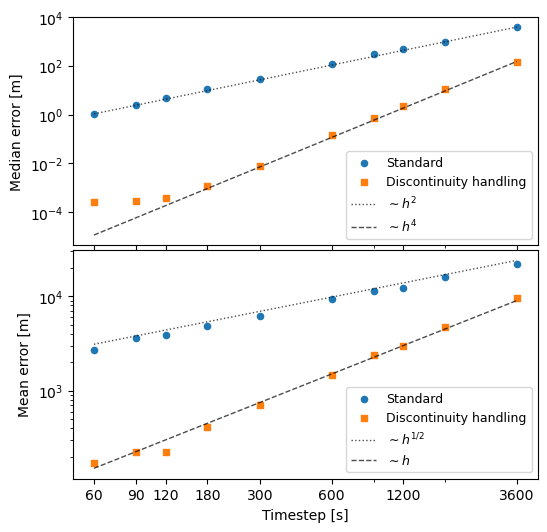

In [5]:
# Load initial positions
X0 = np.loadtxt('../data/initial_positions_nordic4_forwards_both.txt', skiprows=1)

filenames = [
    f'../results/backward_run_standard_rk4_nordic4_linear.hdf5',
    f'../results/backward_run_discontinuity_handling_rk4_nordic4_linear.hdf5',
    ]

fig, ax = plt.subplots(nrows=2, figsize=(6,6), sharex=True)

for filename in filenames:

    keys, data = get_data(filename)
    errs_mean = np.zeros(len(keys))
    errs_median = np.zeros(len(keys))
    errs_pct = np.zeros(len(keys))
    
    for i, dt in enumerate(keys[:]):
        all_errs = get_distances(X0, data[dt], relative=False)
        errs_mean[i] = np.mean(all_errs)
        errs_median[i] = np.median(all_errs)
        errs_pct[i] = np.percentile(all_errs, 95)

    if 'discontinuity_handling' in filename:
        label='Discontinuity handling'
        marker = 's'
        s=15
    else:
        label='Standard'
        marker = 'o'
        s=20
    
    ax[0].scatter(keys[:], errs_median, s=s, marker=marker, label=label)
    ax[1].scatter(keys[:], errs_mean, s=s, marker=marker, label=label)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].plot(keys, 3e-4*keys**2, ':', c='k', alpha=0.7, lw=1, label='$\\sim h^2$')
ax[0].plot(keys, 9e-13*keys**4, '--', c='k', alpha=0.7, lw=1, label='$\\sim h^4$')

ax[1].plot(keys, 4e2*keys**0.5, ':', c='k', alpha=0.7, lw=1, label='$\\sim h^{1/2}$')
ax[1].plot(keys, 2.5e0*keys**1, '--', c='k', alpha=0.7, lw=1, label='$\\sim h$')

ax[0].set_ylabel('Median error [m]')
ax[1].set_ylabel('Mean error [m]')
ax[1].set_xlabel('Timestep [s]')
    
ax[-1].set_xticks(keys, minor=True)
ax[-1].set_xticks([60, 90, 120, 180, 300, 600, 1200, 3600])
ax[-1].set_xticklabels([60, 90, 120, 180, 300, 600, 1200, 3600])

for a in ax:
    a.legend(fontsize=9)

plt.subplots_adjust(hspace=0.02)
plt.savefig('error_backtracking.png', dpi=240)
plt.savefig('error_backtracking.pdf', bbox_inches='tight')